# Project Foundations for Data Science: FoodHub Data Analysis

**Marks: 60**

### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [ ]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

### Understanding the structure of the data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# read the data, this code was used to grab the data downloaded to this device
df = pd.read_csv('/content/drive/MyDrive/Python Course/used_cars.csv')


NameError: name 'pd' is not defined

#### Observations:

The DataFrame has 9 columns as mentioned in the Data Dictionary. Data in each row corresponds to the order placed by a customer.

### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [ ]:
# Code used to get the number of rows and columns in a pandas DataFrame
df.shape

(1898, 9)

#### Observations: There are 1898 rows and 9 columns.


### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [ ]:
# Use info() to print a concise summary of the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations: The datatypes of the 9 different columns are order_id, customer_id, restuarant_name, cuisine_type, cost_of_the_order, day_of_the_week, rating, food_preparation_time, and delivery_time.


### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [ ]:
# Code to find the number of missing (null) values in each column of the DataFrame. Sum is used to convert them to numbers and add them up.
df.isnull().sum()

,0
order_id,0
customer_id,0
restaurant_name,0
cuisine_type,0
cost_of_the_order,0
day_of_the_week,0
rating,0
food_preparation_time,0
delivery_time,0


#### Observations: There seems to be no missing values in the data.


### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [ ]:
# Code to get a statistical summary of the data, representing the numberic columns
df.describe()

,order_id,customer_id,cost_of_the_order,food_preparation_time,delivery_time
count,1.898000e+03,1898.000000,1898.000000,1898.000000,1898.000000
mean,1.477496e+06,171168.478398,16.498851,27.371970,24.161749
std,5.480497e+02,113698.139743,7.483812,4.632481,4.972637
min,1.476547e+06,1311.000000,4.470000,20.000000,15.000000
25%,1.477021e+06,77787.750000,12.080000,23.000000,20.000000
50%,1.477496e+06,128600.000000,14.140000,27.000000,25.000000
75%,1.477970e+06,270525.000000,22.297500,31.000000,28.000000
max,1.478444e+06,405334.000000,35.410000,35.000000,33.000000


#### Observations: Minimum time is 20.0, average time is 27.37, maximum time is 35.0.


### **Question 5:** How many orders are not rated? [1 mark]

In [ ]:
# Code to get the frequncy of each rating values
df['rating'].value_counts()

,count
rating,
Not given,736
5,588
4,386
3,188


#### Observations: There are 736 orders that are not rated.


### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

In [ ]:
# Code to find the frequency of the order_id
df['order_id'].value_counts()

,count
order_id,
1478056,1
1477147,1
1477685,1
1477070,1
1477334,1
...,...
1478198,1
1477449,1
1476966,1


##Observation: Theoritically, all order ID numbers should be different, and as this is the case, we can know that there wasn't a duplication of the data.

In [ ]:
# Code to find the frequency of each customer_id
df['customer_id'].value_counts()

,count
customer_id,
52832,13
47440,10
83287,9
250494,8
259341,7
...,...
143926,1
89574,1
157711,1


##Observation: Here, we can see the number of times each customer ordered. Helpful to see which customers are frequent users of the app.

In [ ]:
# Code to find the frequncy of orders for each restuarant
df['restaurant_name'].value_counts()

,count
restaurant_name,
Shake Shack,219
The Meatball Shop,132
Blue Ribbon Sushi,119
Blue Ribbon Fried Chicken,96
Parm,68
...,...
Rye House,1
Hiroko's Place,1
Frank Restaurant,1


##Observation: Through this, we can see which which restuarants had the most orders. Shake Shack, The Meatball Shop, and Blue Ribbon Sushi are the top 3 restuarants that people placed their orders.

In [ ]:
# Code to find out the frequency of each cuisine_type
df['cuisine_type'].value_counts()

,count
cuisine_type,
American,584
Japanese,470
Italian,298
Chinese,215
Mexican,77
Indian,73
Middle Eastern,49
Mediterranean,46
Thai,19


##Observation: From here, we can see the number of orders based on the cuisine type. American, Japanese, Italian, and Chinese seem to be the popular cuisine types.

<Figure size 640x480 with 0 Axes>

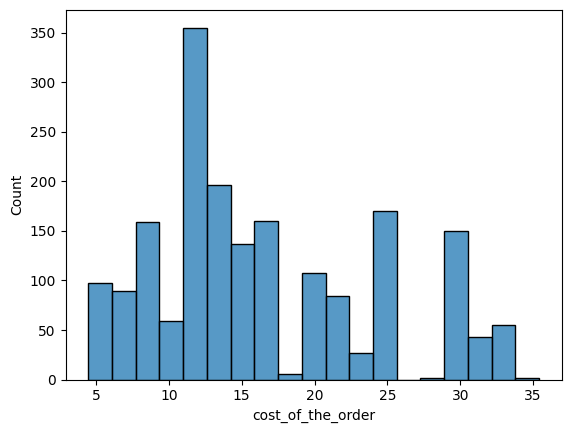

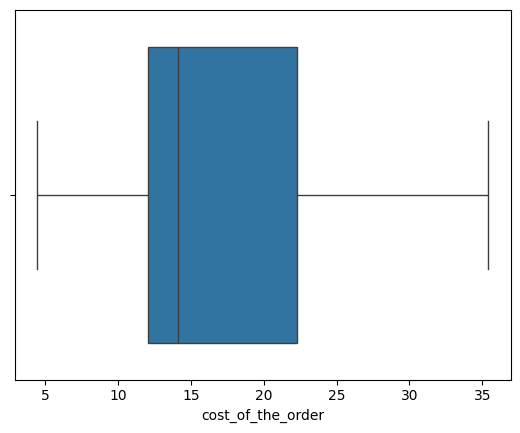

<Figure size 640x480 with 0 Axes>

In [ ]:
# sns.histplot() to bring up the histogram with cost of order in the x-axis
sns.histplot(data=df,x='cost_of_the_order')
plt.figure()
#sns.boxplot() to bring up the histogram with cost of order in the x-axis
sns.boxplot(data=df,x='cost_of_the_order')
plt.figure()
# figure() was used to plot separately, and countplot() was not used as it is suited for categorical variables

##Observation: The histogram shows the distribution of order costs by grouping the different costs into intervals. We can see that the most amount of orders, around 350 orders, cost around 11 to 13. The boxplot shows the min/max values along with the quartiles and mean. We can see that the average order cost for the dataset is around 14.

In [ ]:
# Code to bring up number of orders placed on which day of the week
df['day_of_the_week'].value_counts()

,count
day_of_the_week,
Weekend,1351
Weekday,547


##Observation: We can see that for this dataset, there were 1351 orders placed on weekends and 547 orders placed on weekdays.

<Axes: xlabel='day_of_the_week', ylabel='count'>

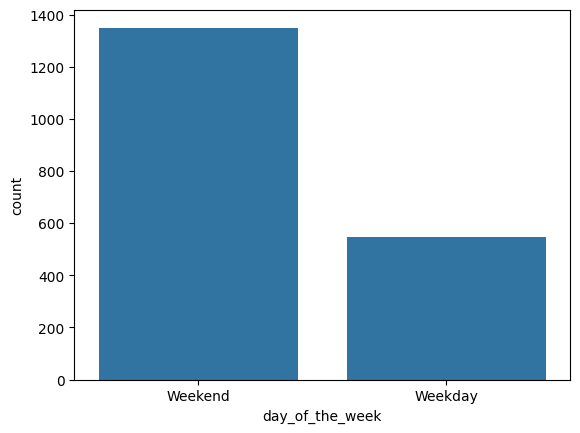

In [ ]:
# sns.countplot() to show a countplot of how many orders placed on weekend and weekday
sns.countplot(data=df,x='day_of_the_week')

##Observation: The plot helps visualize the difference in order numbers between weekends and weekdays. We can see a big diffence.

In [ ]:
# Code to show the frequency of each rating numbers
df['rating'].value_counts()

,count
rating,
Not given,736
5,588
4,386
3,188


##Observation: There are 588 ratings of 5, 386 ratings of 4, 188 ratings of 3, and 736 orders were left with no rating.

---



<Axes: xlabel='rating', ylabel='Count'>

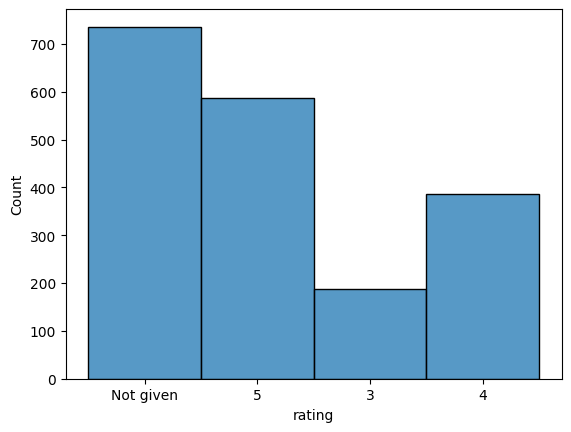

In [ ]:
# sns.countplot to give countplot of the reviews
# Although the reviews are numbers, they are considered categorical
sns.countplot(data=df,x='rating')

##Observation: The plot shows the distribution of different rating values left for each order. Most orders were 5 or not given.

In [ ]:
# Code to bring up frequncy of different preparation times
df['food_preparation_time'].value_counts()

,count
food_preparation_time,
21,135
23,123
27,123
22,123
28,121
24,121
30,119
20,119
33,118


##Observation: All of the preparation times are in a certain range with no outliers, the most frequent time being 21.

<Figure size 640x480 with 0 Axes>

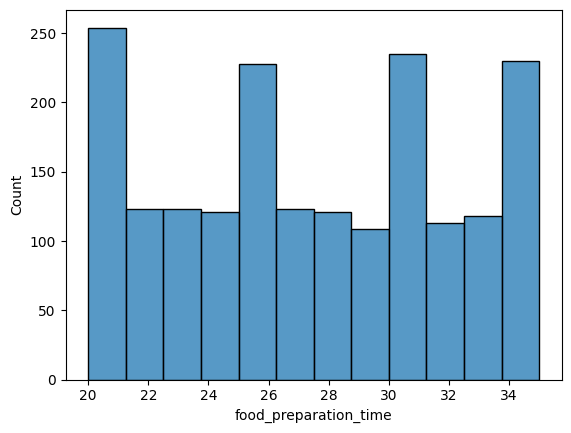

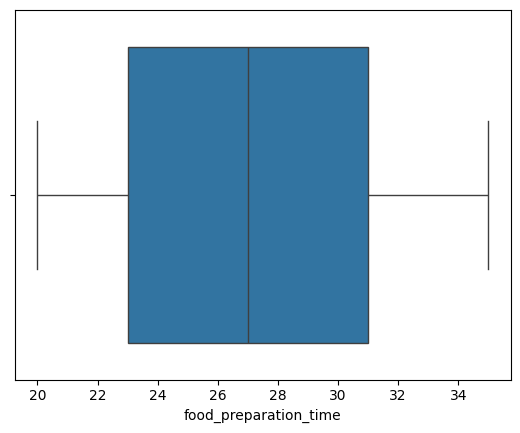

<Figure size 640x480 with 0 Axes>

In [ ]:
# Code to bring up histogram of food preparation time
sns.histplot(data=df,x='food_preparation_time')
plt.figure()
# Code to bring up boxplot of food preparation time
sns.boxplot(data=df,x='food_preparation_time')
plt.figure()

##Observation: The histogram shows the distribution of values for the food preparation time. The most frequent time it took was around 20 to 21 minutes. The boxplot shows the min/max, quartiles, and the mean values. The average time of preparation for this data shows to be around 27 minutes.

In [ ]:
# Code for bringing up the frequencies of each delivery times
df['delivery_time'].value_counts()

,count
delivery_time,
24,162
29,148
28,148
26,141
27,138
30,133
25,120
19,90
16,90


##Observation: We are able to see how many deliveries took how many minutes. We can also see that all most frequent delivery times were in that 25~30 minute marker.

<Figure size 640x480 with 0 Axes>

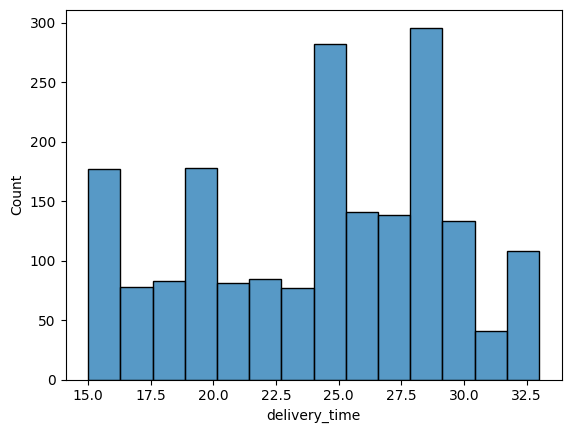

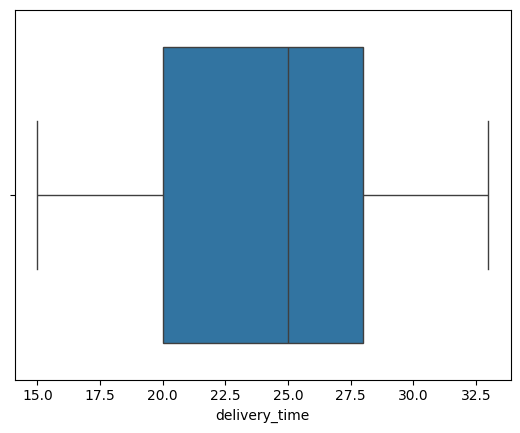

<Figure size 640x480 with 0 Axes>

In [ ]:
# sns.histplot() to bring up histogram of delivery times
sns.histplot(data=df,x='delivery_time')
plt.figure()
# sns.boxplot() to bring up boxplot of delivery times
sns.boxplot(data=df,x='delivery_time')
plt.figure()

##Observation: The histogram shows a distrubution of number of orders and the delivery times. The most frequent delivery time shown is between 27.5 to 30 minutes. The boxplot shows the min/max, quartiles, and mean values of delivery time. We can see that the fastest delivery is 15, slowest delivery is 33, and the average devliery time is around 25 mintues.

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [ ]:
# Value.count() to bring up the total number of orders places for each restaurant, and head() to automatically bring up the top 5
df['restaurant_name'].value_counts().head()

,count
restaurant_name,
Shake Shack,219
The Meatball Shop,132
Blue Ribbon Sushi,119
Blue Ribbon Fried Chicken,96
Parm,68


#### Observations: The top 5 restaurants are "Shake Shack", "The Meatball Shop", "Blue Ribbon Sushi", "Blue Ribbon Fried Chicken", and "Parm".


### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [ ]:
# df['day_of_the_week']=='Weekend' to focus parameter to weekends, ['cuisine_type'].value_counts().head() to get first 5 popular cuisine
df[df['day_of_the_week']=='Weekend']['cuisine_type'].value_counts().head()

,count
cuisine_type,
American,415
Japanese,335
Italian,207
Chinese,163
Mexican,53


##Observation: The most popular is American cuisine on weekends.


### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [ ]:
# df_more_than_20 brings data of all orders that cost more than 20 dollars
df_more_than_20 = df[df['cost_of_the_order'] > 20]
# shape[0] is used to represent number of rows, so number of orders
# percentage would be number of orders that are more than 20 dollars / total number of orders multiplied by 100
percentage = (df_more_than_20.shape[0] / df.shape[0]) * 100
print(percentage)

29.24130663856691


#### Observations: By dividing the total number of orders that cost more than 20 dollars by the general total number of orders and multyiplying by 100, we get a value of 29.24%. So, around 29% of the orders cost more than 20 dollars.


### **Question 10**: What is the mean order delivery time? [1 mark]

In [ ]:
# .mean() gets the mean value of all deliver time values
mean_delivery_time = df['delivery_time'].mean()
print(mean_delivery_time)

24.161749209694417


#### Observations: The mean order delivery time comes to be around 24.16 minutes.


### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [ ]:
# .value_counts() to get the number of orders places for each customer_id, and head(3) to get the top 3 counts
df['customer_id'].value_counts().head(3)

,count
customer_id,
52832,13
47440,10
83287,9


#### Observations: The top 3 customer IDs associated to the most frequent orders are '52832', '47440', and '83287'.


### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


<Axes: xlabel='cuisine_type', ylabel='cost_of_the_order'>

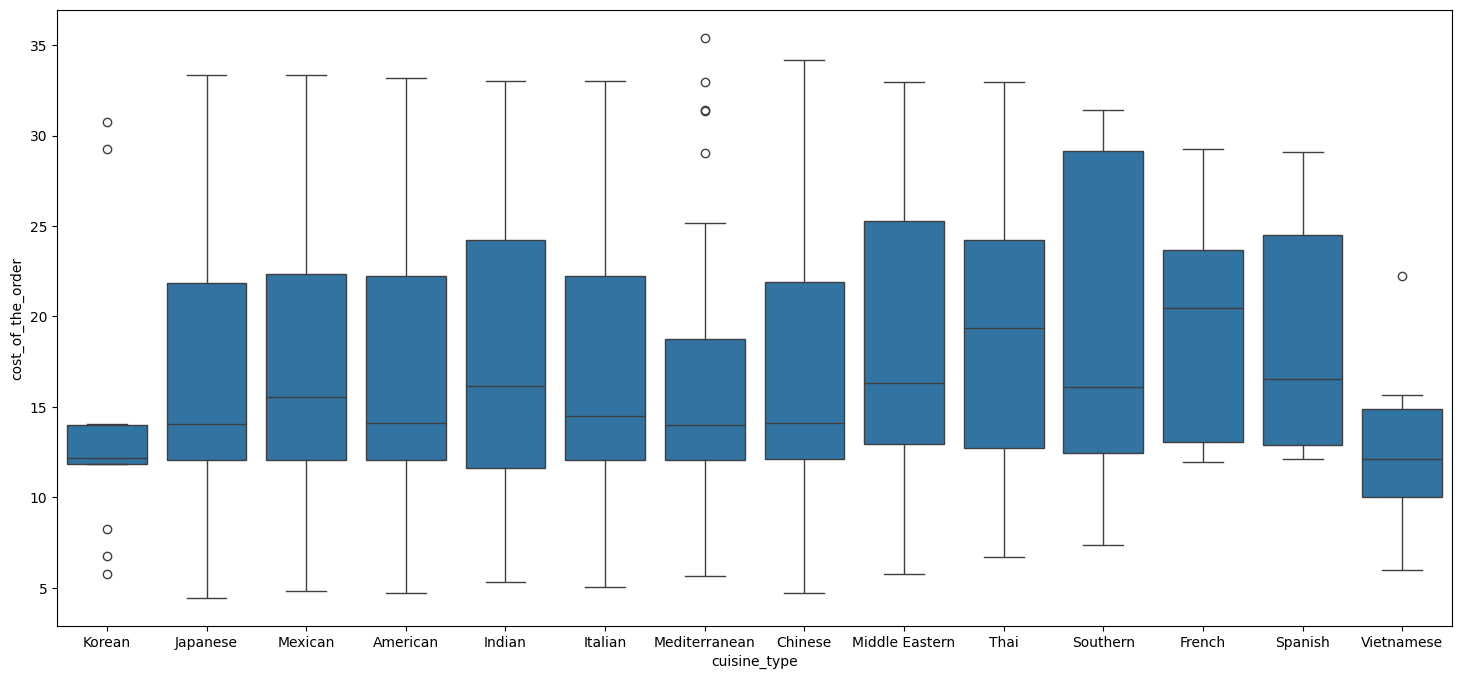

In [ ]:
# Code for boxplot of relationship between cuisine type and order cost
plt.figure(figsize=(18,8))
sns.boxplot(data=df,x='cuisine_type',y='cost_of_the_order')

##Observation: The boxplots shows the cost of order for each cuisine type. The Korean and Vietnamese cuisine has a lower maximum cost value than the others, but the Korean quisine has a higher minimum cost value. There are considerable outliers in the Korean and Mediterranean cuisine.

<Axes: xlabel='cuisine_type', ylabel='food_preparation_time'>

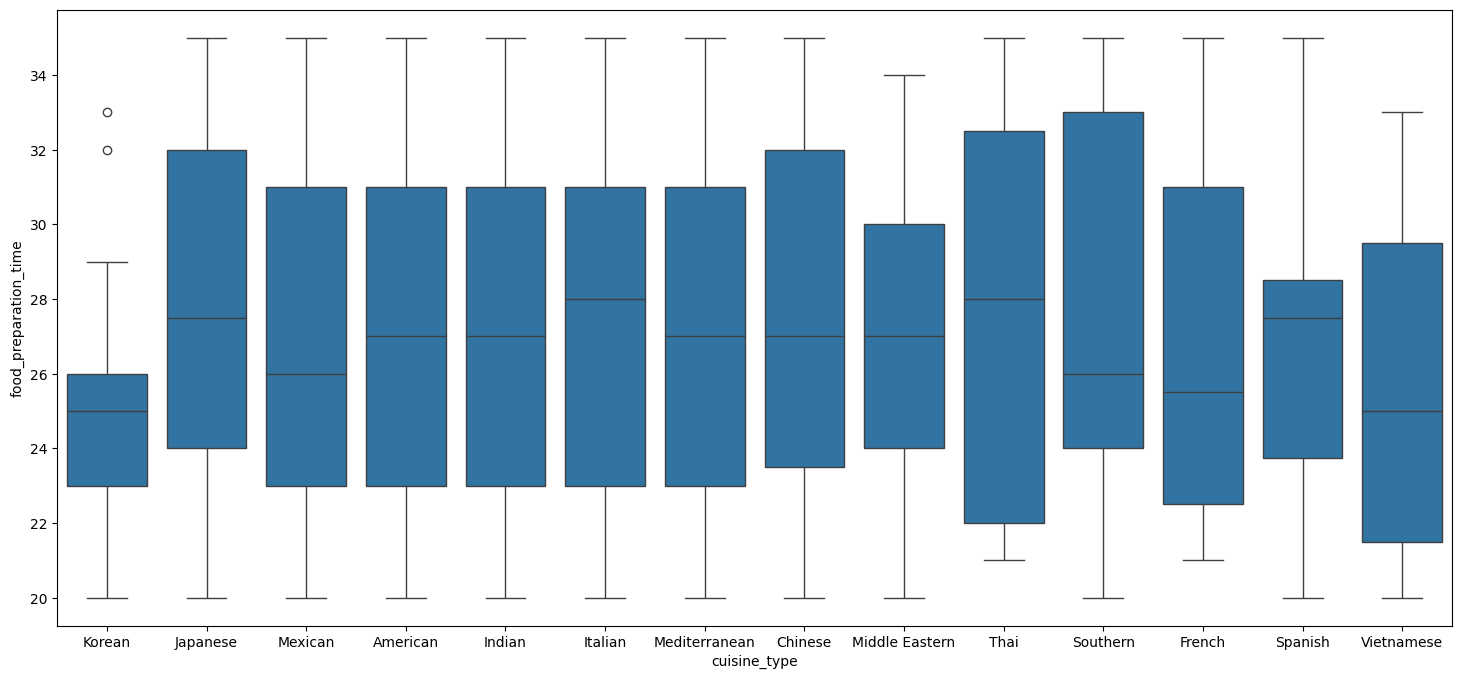

In [ ]:
# Code for boxplot of relationship between cuisine type and food preparation time
plt.figure(figsize=(18,8))
sns.boxplot(data=df,x='cuisine_type',y='food_preparation_time')

##Observation: The boxplots show the distrubution of food preparation time for each cuisine type. While all the cuisines have a very similar minimum time, Korean cuisine has a lower maximum time than the others. However, a few outlier values were found in this dataset that goes up to more than 32 minutes. Italian, Thai and Spanish cuisines had the highest mean values of preparation time.

<Axes: xlabel='day_of_the_week', ylabel='delivery_time'>

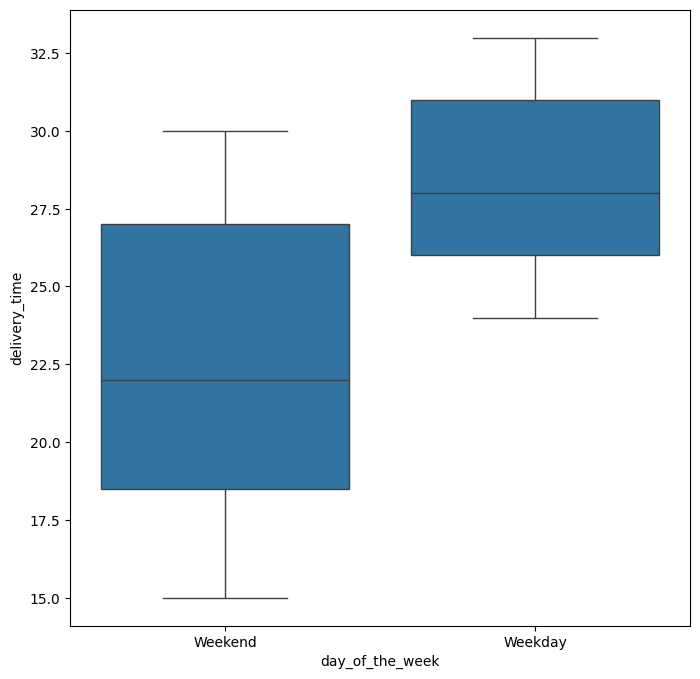

In [ ]:
# Code for boxplots of relationship between day of the week and delivery time
plt.figure(figsize=(8,8))
sns.boxplot(data=df,x='day_of_the_week',y='delivery_time')

##Observation:  We can see here that the delivery time overall is faster on the weekends. The average weekend delivery time is around 22 minutes, while on weekdays, it takes around 28 minutes. The minimum delivery time on weekend is also much lower than that of the weekday.

<Axes: xlabel='rating', ylabel='delivery_time'>

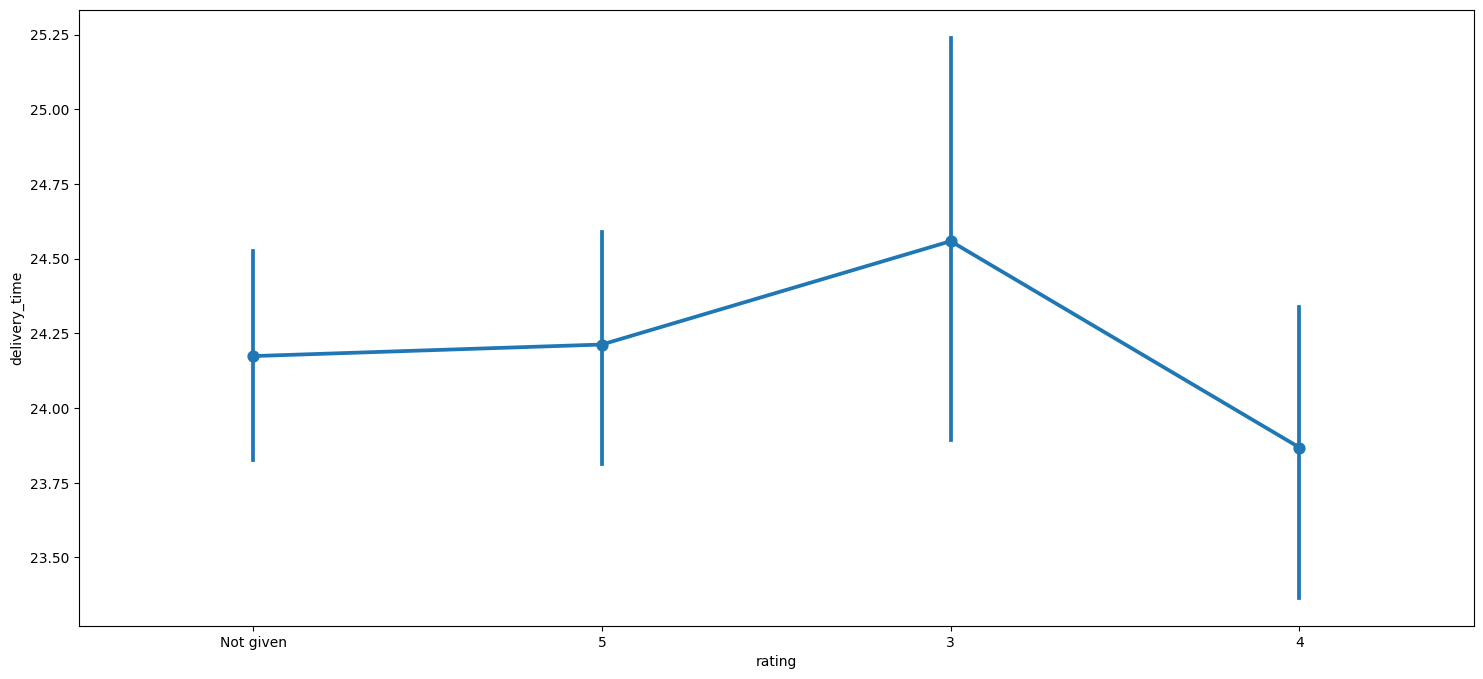

In [ ]:
# Code for pointplot of the relationship between rating and delivery time
plt.figure(figsize=(18,8))
sns.pointplot(data=df,x='rating',y='delivery_time')

##Observation: The lowest ratings of 3 had longer delivery times, while the highest ratings of 5 had shorter delivery times in comparison. Ironically, the ratings of 4 had overall shorter delivery times than 5, so we would had to assume that there was something wrong with the quality in sacrifice of better delivery time. "Not given" ratings are assumibly around the same of that of ratings of 5 as there were no negative comments to leave.

<Axes: xlabel='rating', ylabel='food_preparation_time'>

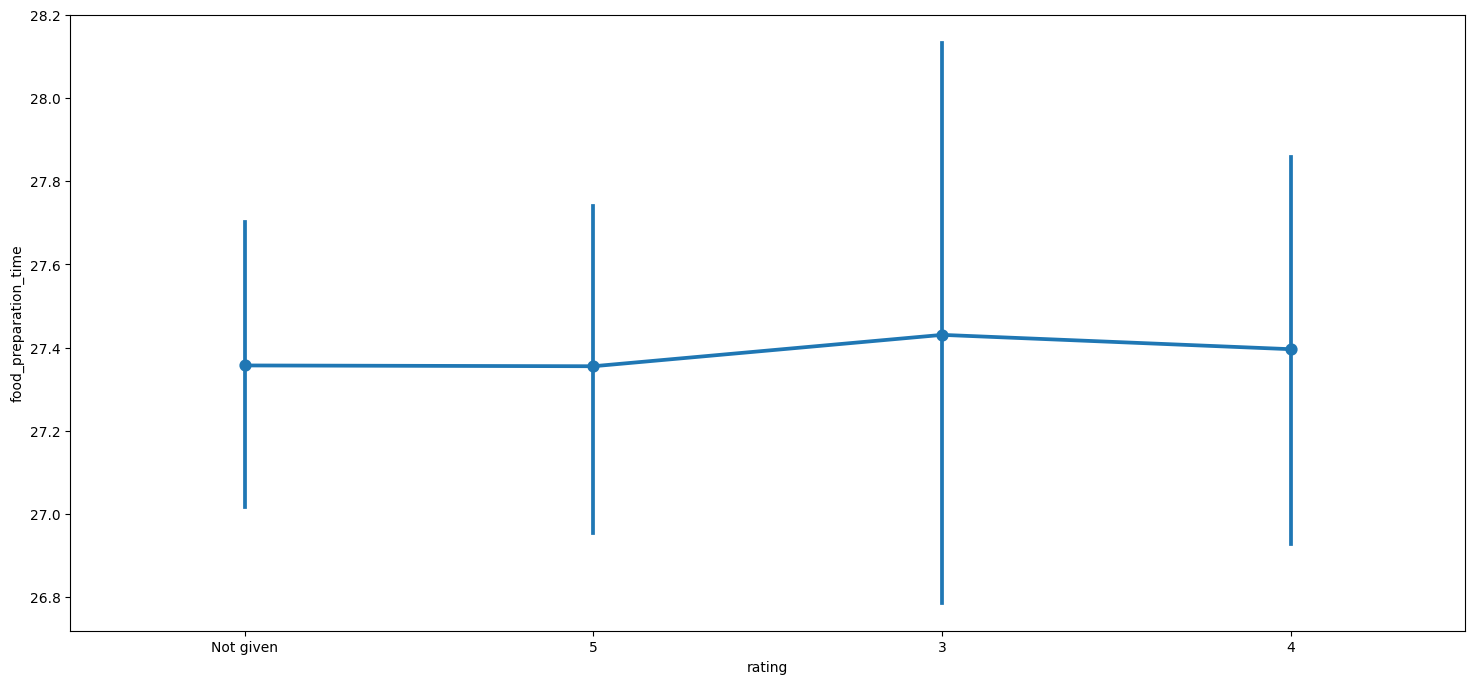

In [ ]:
# Code of pointplot for the relationship between rating and food preparation time
plt.figure(figsize=(18,8))
sns.pointplot(data=df,x='rating',y='food_preparation_time')

##Observation: The lowest rating of 3 had the most inconsistent preparation time and the highest average time out of all. The plot shows that the higher the rating, the average preparation time is shortest and the overall times are more consistent with a shorter range.

<Axes: xlabel='rating', ylabel='cost_of_the_order'>

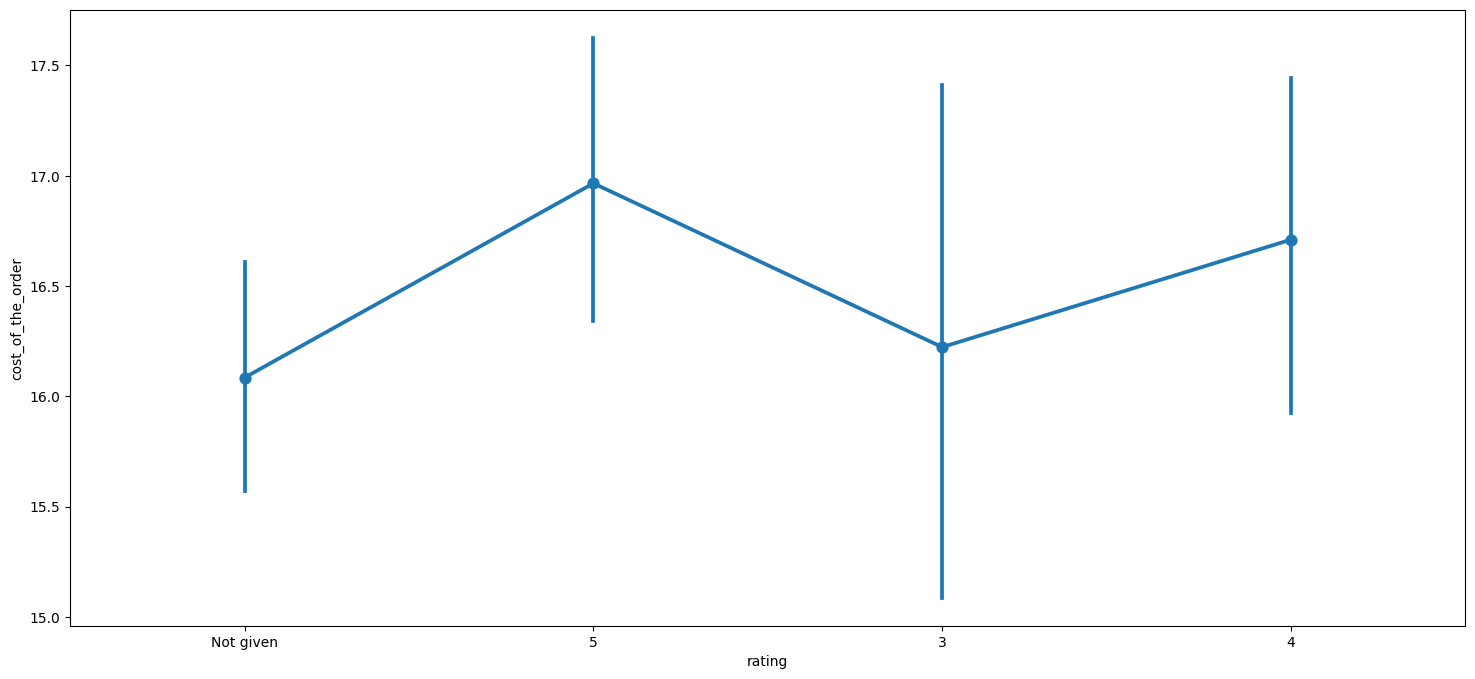

In [ ]:
# Code of pointplot for the relationship between the rating and cost of the order
plt.figure(figsize=(18,8))
sns.pointplot(data=df,x='rating',y='cost_of_the_order')

##Observation: We can see that the highest rating had the highest overall price for the orders. The lowest rating of 3 had the widest range of price and the second lowest average of price. The higher the rating, the more consistant the order prices are.

<Axes: >

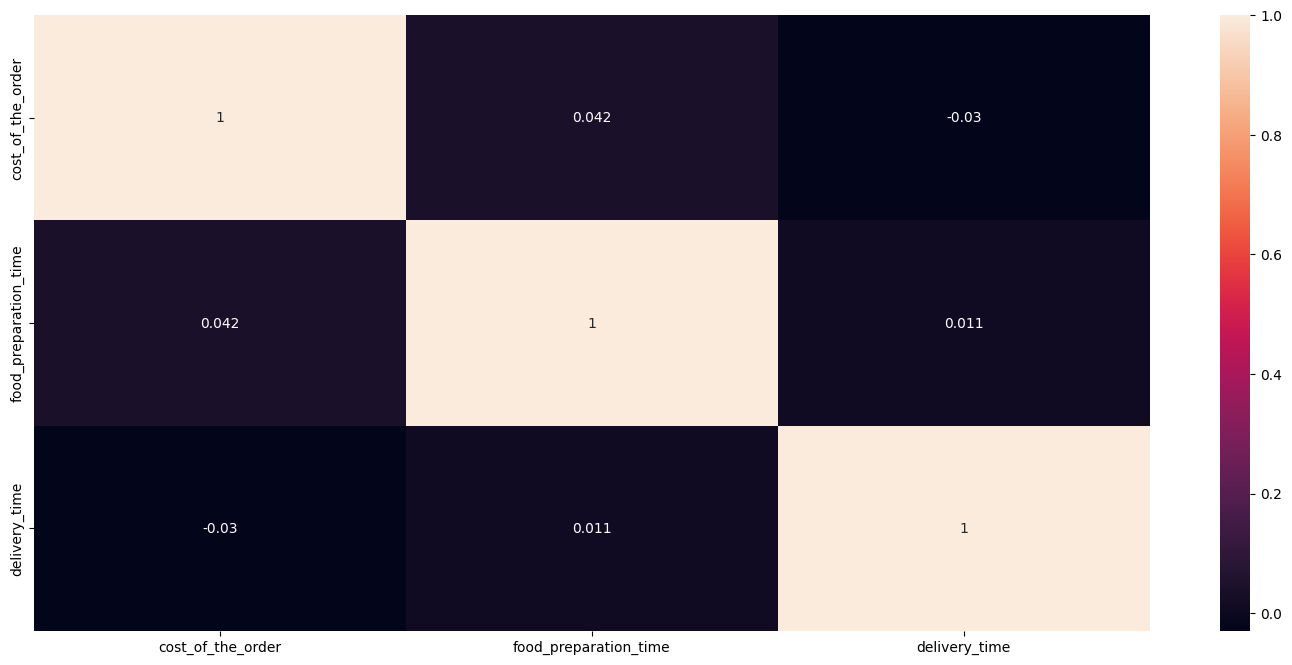

In [ ]:
# Code of heatmap for the three variables
col_list = ['cost_of_the_order','food_preparation_time','delivery_time']
plt.figure(figsize=(18,8))
sns.heatmap(df[col_list].corr(),annot=True)

##Observation: The heatmap shows overall correlation values for the respoding variables. All of the numbers here are below 0.05, and so the 3 variables used here seem to barely correlate to each other.

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [ ]:
# Group by restaurant and calculate the count and mean of ratings
restaurant_ratings = df.groupby('restaurant_name')['rating'].agg(['count', 'mean'])

# Filter for restaurants with rating count >= 50 and average rating > 4
promotional_restaurants = restaurant_ratings[(restaurant_ratings['count'] >= 50) & (restaurant_ratings['mean'] > 4)]

# Display the resulting DataFrame
display(promotional_restaurants)

,count,mean
restaurant_name,,
Blue Ribbon Fried Chicken,64,4.328125
Blue Ribbon Sushi,73,4.219178
Shake Shack,133,4.278195
The Meatball Shop,84,4.511905


##Observations: The restaurants that fulfill the requirement of having more tha 50 ratings that average 4 and above are "Blue Ribbon Fried Chicken", "Blue Ribbon Sushi", "Shake Shack", and "The Meatball Shop".

### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [ ]:
# If-Elif-Else Statements for the company revenue depending on price of the order
def company_revenue(x):
  if x>20:
    return x*0.25
  elif x>5:
    return x*0.15
  else:
    return 0
# Code for the revenue cost of each order
df['Revenue']=df['cost_of_the_order'].apply(company_revenue)
# Code of total company revenue for all orders
company_revenue = df['Revenue'].sum()
print(company_revenue)

6166.303


#### Observations: The total revenue of the company earned from all the orders in this dataset comes up to around 6166 dollars and 30 cents


### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [ ]:
# Calculate the total time for each order
df['total_time'] = df['food_preparation_time'] + df['delivery_time']

# Count the number of orders where total_time is greater than 60
orders_over_60_minutes = df[df['total_time'] > 60].shape[0]

# Calculate the percentage of orders over 60 minutes
percentage_over_60_minutes = (orders_over_60_minutes / df.shape[0]) * 100

print(percentage_over_60_minutes)

10.537407797681771


#### Observations: Around 10.54 percent of orders take more than 60 minutes to get delivered.


### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [ ]:
# Get the mean delivery times for weekday and weekends for all the orders
print(df.groupby('day_of_the_week')['delivery_time'].mean())

day_of_the_week
Weekday    28.340037
Weekend    22.470022
Name: delivery_time, dtype: float64


#### Observations: The mean delivery time on weekdays is about 28.34 minutes, and the mean delivery time on weekends is about 22.47 minutes.


### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### Conclusions:
*  The higher the rating, the less range of each variable, such as food preparation time, delivery time, and order cost
*  While there are less weekday orders, there are longer delivery times
*  Korean Cuisine had outliers in preparation time
*  736 out of 1898 orders were not rated
*  The restuarant "Parm" had over 50 ratings but below a 4.

### Recommendations:

*  For restuarants with lower overall ratings, such as "Parm", we should progress with a way to be more consistant in the food prepping and delivery times
*  Need to lessen the time of weekday delivery times by either hiring more drivers or covering a lesser radius for order availibility areas
*  Need to find a way to seduce customers to leave more reviews with a coupon system or reward points. More reviews can help with better quality of data
*  Korean cuisine restuarants should be checked to see what causes the outliers of preparation time, when it has the shortest maximum time out of all the restaurants